<a href="https://colab.research.google.com/github/Ibrah-N/Deep-Learning-Projects-Computer-Vision/blob/main/Pytorch_2_autograde_and_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AutoGrad Basic

In [ ]:
import torch

In [ ]:
x = torch.tensor(5., requires_grad=True)
x_sq = x ** 2


# Perform backward pass to compute gradients
x_sq.backward()

print(f"Derivative of x^2 with respect to x: {x.grad}")

Derivative of x^2 with respect to x: 10.0


In [ ]:
y = torch.tensor(0., requires_grad=True)

z = torch.sigmoid(y)

z.backward()

print(f"Derivative fo sigmoid(y) with respect to y is {y.grad}")

Derivative fo sigmoid(y) with respect to y is 0.25


In [ ]:
print(z.detach())

tensor(0.5000)


In [ ]:
# inputs
x = torch.tensor(10)
y = torch.tensor(2)



# weights
w = torch.tensor(0.67, requires_grad=True)
b = torch.tensor(0.96, requires_grad=True)

In [ ]:

# forward pass
y_hat = w * x + b


# calculate loss
loss = (y_hat - y) ** 2

# backward pass
loss.backward()

print(f"Loss: {loss.detach().numpy()}, {w.grad}, {b.grad}")

# update the params
with torch.no_grad():
  w -= 0.001 * w.grad
  b -= 0.001 * b.grad


w.grad.zero_()
b.grad.zero_()

Loss: 8.272757530212402, 57.524803161621094, 5.752480506896973


tensor(0.)

## building regression model

In [ ]:
import torch

print(torch.__version__)

2.10.0+cpu


In [ ]:
!python -m pip install git+https://github.com/treforevans/uci_datasets.git

  Cloning https://github.com/treforevans/uci_datasets.git to /tmp/pip-req-build-i56b7wwk
  Running command git clone --filter=blob:none --quiet https://github.com/treforevans/uci_datasets.git /tmp/pip-req-build-i56b7wwk
  Resolved https://github.com/treforevans/uci_datasets.git to commit f0737523712fe66a1640e4b980b927e8490b58eb
  Preparing metadata (setup.py) ... done
  Created wheel for uci_datasets: filename=uci_datasets-1.1.0-py3-none-any.whl size=327307063 sha256=85098c475f9ac15a4909e77fde70589e98fa6e6ad69a91c40d96a9cc0e66caba
  Stored in directory: /tmp/pip-ephem-wheel-cache-htlsbsmf/wheels/e6/d9/69/2d2e33ddf996abddbfa886b131e0397d70ab610f65f9b8ddb6
Successfully built uci_datasets


In [ ]:
# input data
from uci_datasets import Dataset
data = Dataset("challenger")
x_train, y_train, x_test, y_test = data.get_split(split=0)

challenger dataset, N=23, d=4


In [ ]:
import pandas as pd

x_ = pd.DataFrame(x_train)
y_ = pd.DataFrame(y_train)

y_t = pd.DataFrame(y_test)
x_t = pd.DataFrame(x_test)

In [ ]:
x_.drop(columns=[0], inplace=True)

In [ ]:
x_t.drop(columns=[0], inplace=True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
x_ = scaler.fit_transform(x_)
x_t = scaler.transform(x_t)

scaled_x_train = scaler.transform(x_)
scaled_x_test = scaler.transform(x_t)

In [ ]:
x_train_final = torch.from_numpy(scaled_x_train).float()
y_train_final = torch.from_numpy(y_train).float()


print(x_train_final.shape)
print(y_train_final.shape)

torch.Size([21, 3])
torch.Size([21, 1])


In [ ]:
# == model ==

class RegModel():
  def __init__(self):
    self.w = torch.tensor(1., requires_grad=True)
    self.b = torch.tensor(0., requires_grad=True)


  def forward(self, x):
    # The multiplication w * x will broadcast w across the last dimension of x
    # if x has shape [N, D] and w is scalar, result is [N, D].
    # If you intend w to be a weight vector for each feature, w should be [1, D].
    # Assuming w is a scalar weight applied to all features as a simple regression model.
    return self.w * x + self.b


  def loss_func(self, y, y_pred):
    # Calculate mean squared error across all elements
    return torch.mean((y_pred - y) ** 2)

In [ ]:
# hyper params
learning_rate = torch.tensor(0.001)
epochs = 20

In [ ]:
reg_model = RegModel()

for epoch in range(epochs):

  # forward pass
  x = reg_model.forward(x_train_final)


  print(x)

  break
  # loss calc
  loss = reg_model.loss_func(y_train_final, x)

  print(f"Loss for epoch {epoch + 1}: {loss}")

  loss.backward()

  # update params
  with torch.no_grad():
    reg_model.w -= learning_rate * reg_model.w.grad
    reg_model.b -= learning_rate * reg_model.b.grad


  # reset params
  reg_model.w.grad.zero_()
  reg_model.b.grad.zero_()


Loss for epoch 1: 0.9049648642539978
Loss for epoch 2: 0.9024052619934082
Loss for epoch 3: 0.8998599052429199
Loss for epoch 4: 0.8973290324211121
Loss for epoch 5: 0.8948125243186951
Loss for epoch 6: 0.8923103213310242
Loss for epoch 7: 0.8898221254348755
Loss for epoch 8: 0.8873479962348938
Loss for epoch 9: 0.8848879933357239
Loss for epoch 10: 0.8824418187141418
Loss for epoch 11: 0.8800094127655029
Loss for epoch 12: 0.8775908350944519
Loss for epoch 13: 0.8751859664916992
Loss for epoch 14: 0.8727946281433105
Loss for epoch 15: 0.8704169392585754
Loss for epoch 16: 0.8680524230003357
Loss for epoch 17: 0.8657014966011047
Loss for epoch 18: 0.8633639216423035
Loss for epoch 19: 0.8610392808914185
Loss for epoch 20: 0.8587279319763184


# classification model using pytorch

In [2]:
import torch
print(torch.__version__)

2.10.0+cpu


# Prepare Data

In [125]:
import tensorflow.keras as keras
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()


In [126]:
x_train = x_train[:20000]
y_train = y_train[:20000]

x_test = x_test[:1000]
y_test = y_test[:1000]


print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")


print(f"Shape of X_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (20000, 28, 28)
Shape of y_train: (20000,)
Shape of X_test: (1000, 28, 28)
Shape of y_test: (1000,)


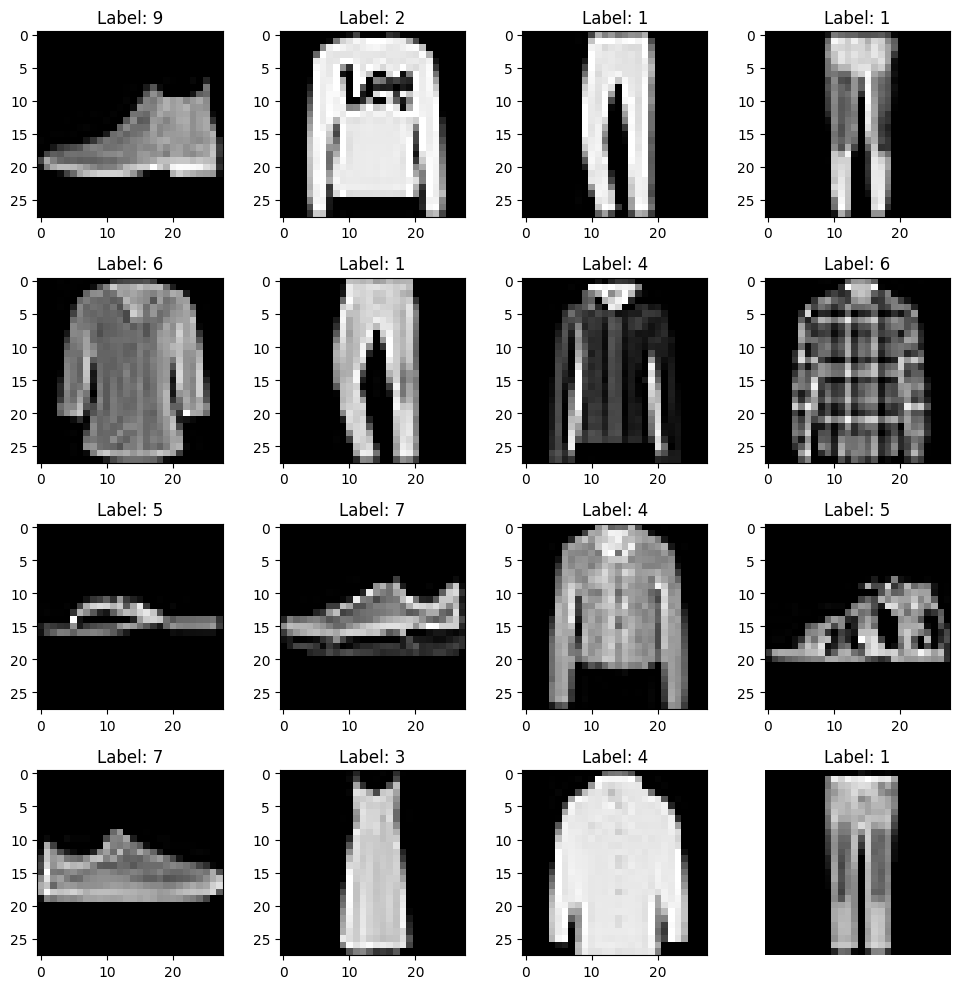

In [127]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))

for i in range(x_test.shape[0]):


  if i == 16:
    break

  ax[i // 4, i % 4].imshow(x_test[i], cmap="gray")
  ax[i // 4, i % 4].set_title(f"Label: {y_test[i]}")
  plt.tight_layout()
  plt.axis("off")



In [128]:
# torch dataset
x_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train).long()


x_test_tensor = torch.from_numpy(x_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

In [129]:
from torch.utils.data import Dataset, DataLoader

In [130]:
def transform(image):

  image = image/255.0

  return image

In [131]:
class CustomDataset(Dataset):

  def __init__(self, x, y, transform=None):
    self.x = x
    self.y = y
    self.transform = transform

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    if self.transform:
      return self.transform(self.x[idx]), self.y[idx]

    return self.x[idx], self.y[idx]

In [132]:
dataset = CustomDataset(x_train_tensor, y_train_tensor, transform)


dataset[0][0].shape, dataset[0][1]

(torch.Size([28, 28]), tensor(9))

In [133]:
val_dataset = CustomDataset(x_test_tensor, y_test_tensor, transform)

# Model

## build Model

In [138]:

class Model(torch.nn.Module):

  def __init__(self, input_dim, output_dim):
    self.input_dim = input_dim
    self.output_dim = output_dim

    super(Model, self).__init__()
    self.flatten = torch.nn.Flatten()
    self.linear_1 = torch.nn.Linear(input_dim, 256)
    self.relu_1 = torch.nn.ReLU()
    self.batch_norm_1 = torch.nn.BatchNorm1d(256)
    self.dropout_1 = torch.nn.Dropout(0.4)


    self.linear_2 = torch.nn.Linear(256, 128)
    self.relu_2 = torch.nn.ReLU()
    self.batch_norm_2 = torch.nn.BatchNorm1d(128)
    self.dropout_2 = torch.nn.Dropout(0.4)

    self.linear_3 = torch.nn.Linear(128, 64)
    self.relu_3 = torch.nn.ReLU()

    self.linear_4 = torch.nn.Linear(64, output_dim)


  def forward(self, x):
    x = self.flatten(x)
    x = self.linear_1(x)
    x = self.relu_1(x)
    x = self.batch_norm_1(x)
    x = self.dropout_1(x)

    x = self.linear_2(x)
    x = self.relu_2(x)
    x = self.batch_norm_2(x)
    x = self.dropout_2(x)


    x = self.linear_3(x)
    x = self.relu_3(x)

    probs = self.linear_4(x)

    return probs

## compile and training loops

In [139]:
# model summary

from torchsummary import summary
model = Model(28*28, 10)

summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
              ReLU-3                  [-1, 256]               0
       BatchNorm1d-4                  [-1, 256]             512
           Dropout-5                  [-1, 256]               0
            Linear-6                  [-1, 128]          32,896
              ReLU-7                  [-1, 128]               0
       BatchNorm1d-8                  [-1, 128]             256
           Dropout-9                  [-1, 128]               0
           Linear-10                   [-1, 64]           8,256
             ReLU-11                   [-1, 64]               0
           Linear-12                   [-1, 10]             650
Total params: 243,530
Trainable params: 243,530
Non-trainable params: 0
-------------------------------

## evaluation

In [140]:
optm = torch.optim.Adam(model.parameters(), lr = 0.0001)
loss_fn = torch.nn.CrossEntropyLoss()

BATCH_SIZE = 32
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [144]:
from IPython.display import clear_output
import time



EPOCHS = 20

for epoch in range(EPOCHS):

  # ======= training pass =========#
  total_loss = 0
  model.train()
  for batch_idx, (train_batch_x, train_batch_y) in enumerate(train_loader):

    # forward pass
    y_pred = model(train_batch_x)

    # compute the loos
    loss = loss_fn(y_pred, train_batch_y)

    # backward pass

    optm.zero_grad()
    loss.backward()

    # update params
    optm.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)
  print(f"Epoch: {epoch + 1}, Loss: {avg_loss}")


  # ======= validation pass =========#
  model.eval()
  with torch.no_grad():

    # training accuracy
    t_total_correct = 0
    t_total_samples = 0
    for batch_idx, (train_batch_x, train_batch_y) in enumerate(train_loader):
      y_pred = model(train_batch_x)
      predicted = torch.argmax(y_pred, -1)
      t_total_samples += train_batch_x.size(0)
      t_total_correct += (predicted == train_batch_y).sum().item()

    t_accuracy = t_total_correct / t_total_samples

    # validation accuracy
    total_correct = 0
    total_samples = 0
    for batch_idx, (test_batch_x, test_batch_y) in enumerate(val_loader):
      y_pred = model(test_batch_x)
      predicted = torch.argmax(y_pred, -1)
      total_samples += test_batch_y.size(0)
      total_correct += (predicted == test_batch_y).sum().item()


    accuracy = total_correct / total_samples
  print(f"Epoch: {epoch + 1}, Training Accuracy {t_accuracy}, Validation Accuracy: {accuracy}")
  print("*"*40)




Epoch: 1, Loss: 0.41961337041854857
Epoch: 1, Training Accuracy 0.90535, Validation Accuracy: 0.874
****************************************
Epoch: 2, Loss: 0.38046729378700256
Epoch: 2, Training Accuracy 0.9057, Validation Accuracy: 0.868
****************************************
Epoch: 3, Loss: 0.38150223042964937
Epoch: 3, Training Accuracy 0.90755, Validation Accuracy: 0.87
****************************************
Epoch: 4, Loss: 0.37296291188001635
Epoch: 4, Training Accuracy 0.90795, Validation Accuracy: 0.872
****************************************
Epoch: 5, Loss: 0.36689680955410003
Epoch: 5, Training Accuracy 0.9143, Validation Accuracy: 0.869
****************************************
Epoch: 6, Loss: 0.3535189541220665
Epoch: 6, Training Accuracy 0.91125, Validation Accuracy: 0.872
****************************************
Epoch: 7, Loss: 0.3516908511161804
Epoch: 7, Training Accuracy 0.9108, Validation Accuracy: 0.874
****************************************
Epoch: 8, Loss: 0.3

****************************************
